# 02 — Comprensión de los datos (Data Understanding)

**Fase CRISP-DM:** Comprensión de los datos.

**Produce:** figuras de exploración en `reports/figures/` y, sobre todo, una lista de decisiones documentadas para tener en cuenta en la siguiente fase.

## 2.1 Importación de librerías y carga de datos

In [33]:
import sys
sys.path.insert(0, "..")  # para poder importar src/ desde notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config, resolve_path
from src.data.load_data import load_raw_data
from src.utils import null_summary
from src.visualization.plots import (
    plot_missing_matrix,
    plot_feature_distributions,
    plot_boxplots,
    plot_correlation_heatmap,
    plot_categorical_counts,
    plot_score_distribution,
)

%matplotlib inline
pd.set_option("display.max_columns", 50)

config = load_config()

# Listas de columnas definidas en config/config.yaml (no se hardcodean aquí).
SCA_FEATURES = config["clustering"]["features"]            # entrada del clustering
PROFILING_FEATURES = config["clustering"]["profiling_features"]  # para perfilar grupos
REFERENCE_COLUMN = config["validation"]["reference_column"]      # Total.Cup.Points
SPECIALTY_THRESHOLD = config["validation"]["specialty_threshold"]  # 80

print("Variables de agrupamiento (SCA):", SCA_FEATURES)
print("Variables de perfilado:", PROFILING_FEATURES)

Variables de agrupamiento (SCA): ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points']
Variables de perfilado: ['Country.of.Origin', 'altitude_mean_meters', 'Variety', 'Processing.Method', 'Color', 'Harvest.Year']


In [34]:
df_arabica = load_raw_data("arabica", config)
df_robusta = load_raw_data("robusta", config)

## 2.2 Descripción general de los conjuntos de datos

La base CQI se distribuye en dos archivos, uno por especie. Se revisan por separado porque, como se verá en 2.2.3, **no comparten el mismo formulario de catación**.

### 2.2.1 Dataset arabica

In [35]:
df_arabica.shape

(1311, 44)

In [36]:
df_arabica.head(10)

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,Producer,Number.of.Bags,Bag.Weight,In.Country.Partner,Harvest.Year,Grading.Date,Owner.1,Variety,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,NaN,Washed / Wet,8.67,8.83,8.67,8.75,8.50,8.42,10.00,10.0,10.00,8.75,90.58,0.12,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.75,8.67,8.50,8.58,8.42,8.42,10.00,10.0,10.00,8.58,89.92,0.12,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,NaN,5,1,Specialty Coffee Association,NaN,"May 31st, 2010",Grounds for Health Admin,Bourbon,NaN,8.42,8.50,8.42,8.42,8.33,8.42,10.00,10.0,10.00,9.25,89.75,0.00,0,0.0,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,Yidnekachew Dabessa Coffee Plantation,320,60 kg,METAD Agricultural Development plc,2014,"March 26th, 2015",Yidnekachew Dabessa,NaN,Natural / Dry,8.17,8.58,8.42,8.42,8.50,8.25,10.00,10.0,10.00,8.67,89.00,0.11,0,0.0,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.25,8.50,8.25,8.50,8.42,8.33,10.00,10.0,10.00,8.58,88.83,0.12,0,0.0,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
5,6,Arabica,ji-ae ahn,Brazil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,30 kg,Specialty Coffee Institute of Asia,2013,"September 3rd, 2013",Ji-Ae Ahn,NaN,Natural / Dry,8.58,8.42,8.42,8.50,8.25,8.33,10.00,10.0,10.00,8.33,88.83,0.11,0,0.0,Bluish-Green,1,"September 3rd, 2014",Specialty Coffee Institute of Asia,726e4891cf2c9a4848768bd34b668124d12c4224,b70da261fcc84831e3e9620c30a8701540abc200,m,NaN,NaN,NaN
6,7,Arabica,hugo valdivia,Peru,NaN,NaN,hvc,NaN,richmond investment-coffee department,NaN,NaN,HVC,100,69 kg,Specialty Coffee Institute of Asia,2012,"September 17th, 2012",Hugo Valdivia,Other,Washed / Wet,8.42,8.50,8.33,8.50,8.25,8.25,10.00,10.0,10.00,8.50,88.75,0.11,0,0.0,Bluish-Green,0,"September 17th, 2013",Specialty Coffee Institute of Asia,726e4891cf2c9a4848768bd34b668124d12c4224,b70da261fcc84831e3e9620c30a8701540abc200,m,NaN,NaN,NaN
7,8,Arabica,ethiopia commodity exchange,Ethiopia,aolme,NaN,c.p.w.e,010/0338,NaN,1570-1700,oromia,Bazen Agricultural & Industrial Dev't Plc,300,60 kg,Ethiopia Commodity Exchange,March 2010,"September 2nd, 2010",Ethiopia Commodity Exchange,NaN,NaN,8

In [37]:
df_arabica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1311 non-null   int64  
 1   Species                1311 non-null   object 
 2   Owner                  1304 non-null   object 
 3   Country.of.Origin      1310 non-null   object 
 4   Farm.Name              955 non-null    object 
 5   Lot.Number             270 non-null    object 
 6   Mill                   1001 non-null   object 
 7   ICO.Number             1163 non-null   object 
 8   Company                1102 non-null   object 
 9   Altitude               1088 non-null   object 
 10  Region                 1254 non-null   object 
 11  Producer               1081 non-null   object 
 12  Number.of.Bags         1311 non-null   int64  
 13  Bag.Weight             1311 non-null   object 
 14  In.Country.Partner     1311 non-null   object 
 15  Harv

**Hallazgo.** `df_arabica` contiene **1 311 registros** y **44 columnas**, con una mezcla de tipos que tiene sentido para este tipo de datos: por un lado, variables numéricas (`float64`/`int64`) que recogen los subpuntajes de catación, la altitud y los defectos; por otro, variables de texto (`object`) que describen el origen, la variedad, el método de procesamiento y los metadatos de certificación. La primera columna, `Unnamed: 0`, resultó ser simplemente el índice de fila que trajo el CSV original, va de 1 a 1312, así que no aporta ninguna información real y se decidide tenerla en cuenta para su eliminación en la fase 03.

### 2.2.2 Dataset robusta

In [38]:
df_robusta.shape

(28, 44)

In [39]:
df_robusta.head(10)

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,Producer,Number.of.Bags,Bag.Weight,In.Country.Partner,Harvest.Year,Grading.Date,Owner.1,Variety,Processing.Method,Fragrance...Aroma,Flavor,Aftertaste,Salt...Acid,Bitter...Sweet,Mouthfeel,Uniform.Cup,Clean.Cup,Balance,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Robusta,ankole coffee producers coop,Uganda,kyangundu cooperative society,NaN,ankole coffee producers,0,ankole coffee producers coop,1488,sheema south western,Ankole coffee producers coop,300,60 kg,Uganda Coffee Development Authority,2013,"June 26th, 2014",Ankole coffee producers coop,NaN,NaN,7.83,8.08,7.75,7.92,8.00,8.25,10.0,10.0,7.92,8.00,83.75,0.12,0,0,Green,2,"June 26th, 2015",Uganda Coffee Development Authority,e36d0270932c3b657e96b7b0278dfd85dc0fe743,03077a1c6bac60e6f514691634a7f6eb5c85aae8,m,1488.0,1488.0,1488.0
1,2,Robusta,nishant gurjer,India,sethuraman estate kaapi royale,25,sethuraman estate,14/1148/2017/21,kaapi royale,3170,chikmagalur karnataka indua,Nishant Gurjer Kaapi Royale,320,60 kg,Specialty Coffee Association,2017,"October 31st, 2017",Nishant Gurjer,NaN,Washed / Wet,8.00,7.75,7.92,8.00,8.00,7.92,10.0,10.0,7.92,8.00,83.50,0.00,0,0,NaN,2,"October 31st, 2018",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,3170.0,3170.0,3170.0
2,3,Robusta,andrew hetzel,India,sethuraman estate,NaN,NaN,0000,sethuraman estate,1000m,chikmagalur,Nishant Gurjer,300,2 kg,Specialty Coffee Association,2015,"April 30th, 2015",Andrew Hetzel,NaN,NaN,7.92,7.83,7.92,8.00,7.83,7.83,10.0,10.0,7.92,8.00,83.25,0.00,0,0,Green,0,"April 29th, 2016",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,1000.0,1000.0,1000.0
3,4,Robusta,ugacof,Uganda,ugacof project area,NaN,ugacof,0,ugacof ltd,1212,central,UGACOF,320,60 kg,Uganda Coffee Development Authority,2013,"July 14th, 2014",UGACOF,NaN,NaN,8.00,7.92,7.92,7.75,7.75,7.83,10.0,10.0,7.75,8.08,83.00,0.12,0,0,Green,7,"July 14th, 2015",Uganda Coffee Development Authority,e36d0270932c3b657e96b7b0278dfd85dc0fe743,03077a1c6bac60e6f514691634a7f6eb5c85aae8,m,1212.0,1212.0,1212.0
4,5,Robusta,katuka development trust ltd,Uganda,katikamu capca farmers association,NaN,katuka development trust,0,katuka development trust ltd,1200-1300,luwero central region,Katuka Development Trust Ltd,1,60 kg,Uganda Coffee Development Authority,2013,"June 26th, 2014",Katuka Development Trust Ltd,NaN,NaN,8.33,7.83,7.83,7.75,7.58,8.25,10.0,10.0,7.75,7.67,83.00,0.12,0,0,Green,3,"June 26th, 2015",Uganda Coffee Development Authority,e36d0270932c3b657e96b7b0278dfd85dc0fe743,03077a1c6bac60e6f514691634a7f6eb5c85aae8,m,1200.0,1300.0,1250.0
5,6,Robusta,andrew hetzel,India,NaN,NaN,(self),NaN,"cafemakers, llc",3000',chikmagalur,Sethuraman Estates,200,1 kg,Specialty Coffee Association,2012,"February 29th, 2012",Andrew Hetzel,NaN,NaN,8.00,7.92,7.67,8.00,7.75,7.75,10.0,10.0,7.92,7.75,82.75,0.00,0,0,Green,0,"February 28th, 2013",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,3000.0,3000.0,3000.0
6,7,Robusta,andrew hetzel,India,sethuraman estates,NaN,NaN,NaN,cafemakers,750m,chikmagalur,Nishant Gurjer,320,2 kg,Specialty Coffee Association,2014,"May 15th, 2014",Andrew Hetzel,NaN,NaN,7.67,7.75,7.83,7.83,8.00,7.92,10.0,10.0,7.75,7.83,82.58,0.00,0,0,Green,0,"May 15th, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,750.0,750.0,750.0
7,8,Robusta,nishant gurjer,India,sethuraman estate kaapi royale,7,sethuraman estate,14/1148/2017/18,kaapi royale,3140,chikmagalur karnataka india,Nishant Gurjer Kaapi Royale,320,60 kg,Specialty Cof

In [40]:
df_robusta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             28 non-null     int64  
 1   Species                28 non-null     object 
 2   Owner                  28 non-null     object 
 3   Country.of.Origin      28 non-null     object 
 4   Farm.Name              25 non-null     object 
 5   Lot.Number             6 non-null      object 
 6   Mill                   20 non-null     object 
 7   ICO.Number             17 non-null     object 
 8   Company                28 non-null     object 
 9   Altitude               25 non-null     object 
 10  Region                 26 non-null     object 
 11  Producer               26 non-null     object 
 12  Number.of.Bags         28 non-null     int64  
 13  Bag.Weight             28 non-null     object 
 14  In.Country.Partner     28 non-null     object 
 15  Harvest.

**Hallazgo.** `df_robusta` tiene apenas **28 registros** (también con **44 columnas**), una muestra demasiado pequeña como para formar grupos propios de manera estable: cualquier clustering hecho solo sobre esta base de datos terminaría con grupos de muy pocos lotes, poco confiables. Esto es algo que hay que tener en cuenta en la fase 03, a la hora de decidir si el análisis se hace solo con arabica o si se busca la forma de combinar ambas especies.

### 2.2.3 Grupos de variables y diferencia de formularios entre especies

In [41]:
# Columnas sensoriales que NO coinciden entre arabica y robusta
solo_arabica = sorted(set(df_arabica.columns) - set(df_robusta.columns))
solo_robusta = sorted(set(df_robusta.columns) - set(df_arabica.columns))
print("Columnas presentes solo en arabica:", solo_arabica)
print("Columnas presentes solo en robusta:", solo_robusta)
print()
comunes = sorted(set(df_arabica.columns) & set(df_robusta.columns))
print(f"Columnas comunes: {len(comunes)} de 44")

Columnas presentes solo en arabica: ['Acidity', 'Aroma', 'Body', 'Sweetness', 'Uniformity']
Columnas presentes solo en robusta: ['Bitter...Sweet', 'Fragrance...Aroma', 'Mouthfeel', 'Salt...Acid', 'Uniform.Cup']

Columnas comunes: 39 de 44


**Hallazgo.** Arabica y robusta se catan con **formularios sensoriales distintos**. Donde arabica usa `Aroma`, `Acidity`, `Body`, `Sweetness` y `Uniformity`, robusta tiene sus propias versiones: `Fragrance...Aroma`, `Salt...Acid`, `Mouthfeel`, `Bitter...Sweet` y `Uniform.Cup`. Las dos especies solo comparten de forma directa `Flavor`, `Aftertaste`, `Balance`, `Clean.Cup`, `Cupper.Points` y `Total.Cup.Points`. Esto significa que **no se pueden unir los subpuntajes de ambas especies sin antes mapearlos entre sí**, y que incluso haciendo ese mapeo, no necesariamente están midiendo lo mismo.

Más allá de ese detalle, conviene agrupar las 44 columnas según el tipo de información que representan:

| Grupo | Ejemplos | Uso previsto en el proyecto |
|---|---|---|
| Identificación / metadatos | `Unnamed: 0`, `Owner`, `Farm.Name`, `Mill`, `Lot.Number`, `ICO.Number`, `Certification.*`, `Grading.Date`, `Expiration` | No se usan (identificadores o administrativos). |
| Origen y manejo | `Country.of.Origin`, `Region`, `Altitude` / `altitude_mean_meters`, `Variety`, `Processing.Method`, `Harvest.Year`, `Number.of.Bags` | **Perfilado** de los grupos (fases 05–06). |
| Evaluación sensorial (SCA) | `Aroma`, `Flavor`, `Aftertaste`, `Acidity`, `Body`, `Balance`, `Uniformity`, `Clean.Cup`, `Sweetness`, `Cupper.Points` | **Entrada del clustering**. |
| Puntaje total | `Total.Cup.Points` | **Referencia** (contraste con los grupos, fase 05). |
| Calidad física del grano | `Moisture`, `Category.One.Defects`, `Category.Two.Defects`, `Quakers`, `Color` | Perfilado / posible apoyo a la definición de calidad. |

## 2.3 Calidad de los datos: duplicados y valores nulos

In [42]:
print("Filas duplicadas  — arabica:", df_arabica.duplicated().sum(),
      "| robusta:", df_robusta.duplicated().sum())

# La base no trae un identificador único de lote real; 'Unnamed: 0' es el índice del CSV.
print("'Unnamed: 0' — valores únicos:", df_arabica['Unnamed: 0'].nunique(),
      "| rango:", df_arabica['Unnamed: 0'].min(), "a", df_arabica['Unnamed: 0'].max())

Filas duplicadas  — arabica: 0 | robusta: 0
'Unnamed: 0' — valores únicos: 1311 | rango: 1 a 1312


In [43]:
null_summary(df_arabica).head(20)

,cantidad_nulos,porcentaje
Lot.Number,1041,79.41
Farm.Name,356,27.15
Mill,310,23.65
Color,267,20.37
Producer,230,17.54
altitude_mean_meters,227,17.32
altitude_high_meters,227,17.32
altitude_low_meters,227,17.32
Altitude,223,17.01
Company,209,15.94


In [44]:
null_summary(df_robusta).head(20)

,cantidad_nulos,porcentaje
Variety,25,89.29
Lot.Number,22,78.57
Processing.Method,18,64.29
ICO.Number,11,39.29
Mill,8,28.57
altitude_low_meters,3,10.71
Altitude,3,10.71
altitude_high_meters,3,10.71
Color,3,10.71
Farm.Name,3,10.71


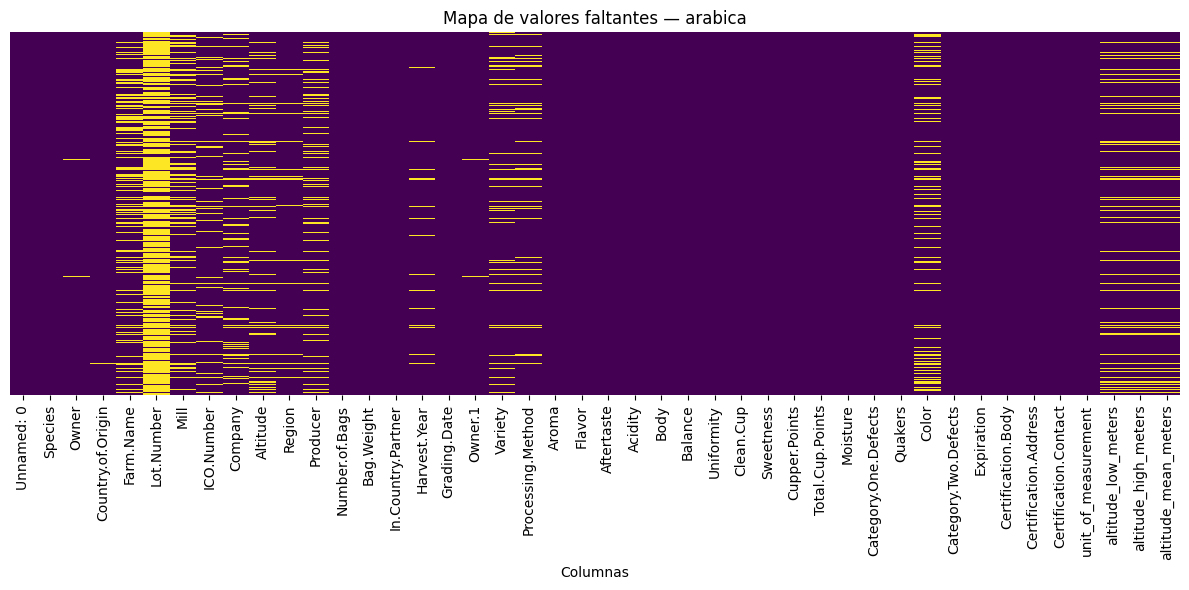

In [45]:
plot_missing_matrix(df_arabica, config, "nulos_arabica.png",
                    title="Mapa de valores faltantes — arabica")
plt.show()

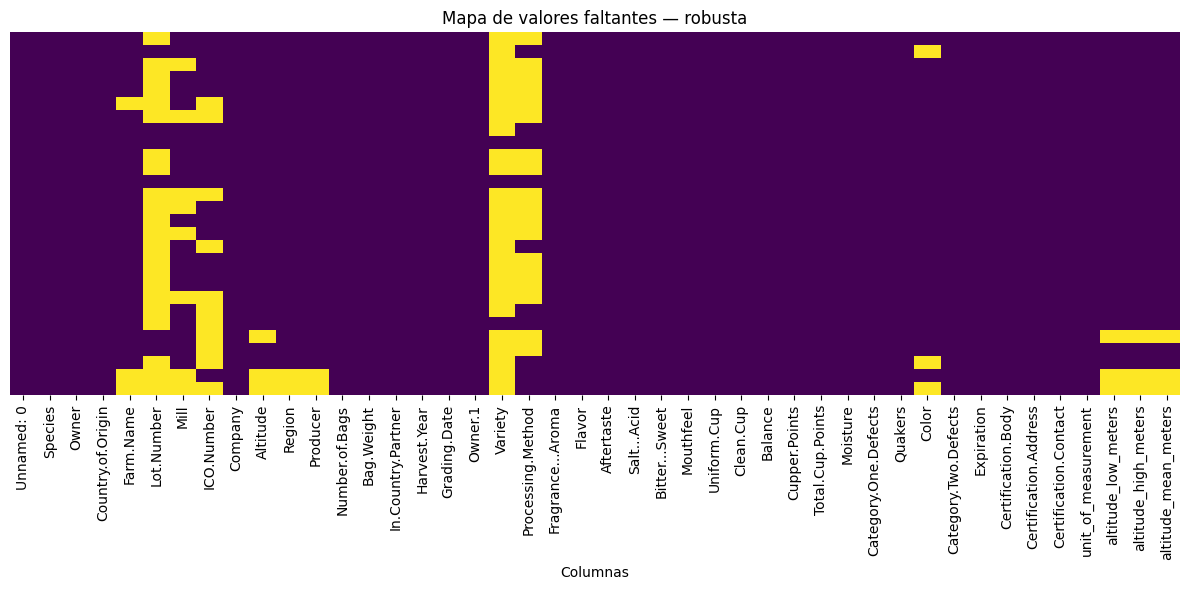

In [46]:
plot_missing_matrix(df_robusta, config, "nulos_robusta.png",
                    title="Mapa de valores faltantes — robusta")
plt.show()

In [69]:
# Variables cuyo porcentaje de valores nulos supera un umbral, en cada base.
UMBRAL_NULOS = 10 

def variables_muy_nulas(df, umbral):
    pct = (df.isna().mean() * 100).round(2)
    return pct[pct > umbral].sort_values(ascending=False)

nulas_arabica = variables_muy_nulas(df_arabica, UMBRAL_NULOS)
nulas_robusta = variables_muy_nulas(df_robusta, UMBRAL_NULOS)

print(f'ARABICA — {len(nulas_arabica)} variables con > {UMBRAL_NULOS}% de nulidad:')
print(nulas_arabica.to_string())
print()
print(f'ROBUSTA — {len(nulas_robusta)} variables con > {UMBRAL_NULOS}% de nulidad:')
print(nulas_robusta.to_string())

ARABICA — 13 variables con > 10% de nulidad:
Lot.Number              79.41
Farm.Name               27.15
Mill                    23.65
Color                   20.37
Producer                17.54
altitude_mean_meters    17.32
altitude_high_meters    17.32
altitude_low_meters     17.32
Altitude                17.01
Company                 15.94
Variety                 15.33
Processing.Method       11.59
ICO.Number              11.29

ROBUSTA — 11 variables con > 10% de nulidad:
Variety                 89.29
Lot.Number              78.57
Processing.Method       64.29
ICO.Number              39.29
Mill                    28.57
Farm.Name               10.71
Altitude                10.71
Color                   10.71
altitude_low_meters     10.71
altitude_high_meters    10.71
altitude_mean_meters    10.71


In [68]:
# ¿Cuáles de esas variables muy nulas se comparten entre las dos bases?
set_arabica = set(nulas_arabica.index)
set_robusta = set(nulas_robusta.index)

compartidas    = sorted(set_arabica & set_robusta)
solo_en_arabica = sorted(set_arabica - set_robusta)
solo_en_robusta = sorted(set_robusta - set_arabica)

print(f'Variables con un alto porcentaje de nulidad en ambas bases ({len(compartidas)}):')
for c in compartidas:
    print(f'  {c:<22} arabica {nulas_arabica[c]:>6.2f}%  |  robusta {nulas_robusta[c]:>6.2f}%')

print(f'\nVariables con un alto porcentaje de nulidad SOLO en arabica ({len(solo_en_arabica)}):')
for c in solo_en_arabica:
    print(f'  {c:<22} arabica {nulas_arabica[c]:>6.2f}%')

print(f'\nVariables con un alto porcentaje de nulidad SOLO en robusta ({len(solo_en_robusta)}):')
for c in solo_en_robusta:
    print(f'  {c:<22} robusta {nulas_robusta[c]:>6.2f}%')

Variables con un alto porcentaje de nulidad en ambas bases (11):
  Altitude               arabica  17.01%  |  robusta  10.71%
  Color                  arabica  20.37%  |  robusta  10.71%
  Farm.Name              arabica  27.15%  |  robusta  10.71%
  ICO.Number             arabica  11.29%  |  robusta  39.29%
  Lot.Number             arabica  79.41%  |  robusta  78.57%
  Mill                   arabica  23.65%  |  robusta  28.57%
  Processing.Method      arabica  11.59%  |  robusta  64.29%
  Variety                arabica  15.33%  |  robusta  89.29%
  altitude_high_meters   arabica  17.32%  |  robusta  10.71%
  altitude_low_meters    arabica  17.32%  |  robusta  10.71%
  altitude_mean_meters   arabica  17.32%  |  robusta  10.71%

Variables con un alto porcentaje de nulidad SOLO en arabica (2):
  Company                arabica  15.94%
  Producer               arabica  17.54%

Variables con un alto porcentaje de nulidad SOLO en robusta (0):


**Hallazgos.**

- No hay filas duplicadas en ninguno de los dos archivos, ni identificadores repetidos (`Unnamed: 0` es único).
- Las columnas con más nulos en arabica son de identificación o de origen: `Lot.Number` (79 %), `Farm.Name` (27 %), `Mill` (24 %), `Color` (20 %), `Producer` (18 %), las tres columnas de altitud (~17 %), `Company` (16 %), `Variety` (15 %) y `Processing.Method` (12 %). `Country.of.Origin` solo tiene 1 valor nulo.
- En robusta los porcentajes son aún más altos (`Variety` 89 %, `Lot.Number` 79 %, `Processing.Method` 64 %), consistente con que solo tiene 28 filas.
- El mapa de valores faltantes muestra que los nulos de altitud, `Farm.Name`, `Mill`, entre otras, tienden a coincidir en las mismas filas y no están repartidos al azar, lo que puede deberse a lotes con poca información de origen reportada.

Con un umbral del 10 % de nulos, 11 variables superan este porcentaje en ambas bases de datos (`Lot.Number`, `Farm.Name`, `Mill`, `ICO.Number`, `Color`, `Variety`, `Processing.Method`, `Altitude`, `altitude_low_meters`, `altitude_high_meters`, `altitude_mean_meters`):

| Variable(s) | % nulos (arabica / robusta) | Recomendación | Motivo |
|---|---|---|---|
| `Lot.Number` | 79 % / 79 % | **Eliminar** | Identificador de lote, sin uso analítico. |
| `Farm.Name`, `Mill`, `ICO.Number`, `Producer`, `Company` | 11–40 % / 11–39 % | **Eliminar** | Identificadores administrativos; no se usan para agrupar ni para perfilar. |
| `Altitude`, `altitude_low_meters`, `altitude_high_meters` | ~17 % / ~11 % | **Eliminar** | Redundantes: para el perfilado podría bastarnos con la variable `altitude_mean_meters`. |
| `altitude_mean_meters` | 17 % / 11 % | **Conservar e Imputar** | Variable de perfilado clave, además tiene valores atípicos. |
| `Variety` | 15 % / 89 % | **Conservar e Imputar** | Variable de perfilado. Aunque en la base de datos de robusta es casi inservible. |
| `Processing.Method` | 12 % / 64 % | **Conservar e Imputar** | Variable de perfilado. |
| `Color` | 20 % / 11 % | **Conservar e Imputar** | Variable de perfilado clave al referirse a información sobre la calidad física del lote. |

## 2.4 Variables cuantitativas: estadísticas descriptivas y valores atípicos

In [49]:
df_arabica.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1311.0,656.000763,378.598733,1.0,328.50,656.00,983.50,1312.00
Number.of.Bags,1311.0,153.887872,129.733734,0.0,14.50,175.00,275.00,1062.00
Aroma,1311.0,7.563806,0.378666,0.0,7.42,7.58,7.75,8.75
Flavor,1311.0,7.518070,0.399979,0.0,7.33,7.58,7.75,8.83
Aftertaste,1311.0,7.397696,0.405119,0.0,7.25,7.42,7.58,8.67
Acidity,1311.0,7.533112,0.381599,0.0,7.33,7.50,7.75,8.75
Body,1311.0,7.517727,0.359213,0.0,7.33,7.50,7.67,8.58
Balance,1311.0,7.517506,0.406316,0.0,7.33,7.50,7.75,8.75
Uniformity,1311.0,9.833394,0.559343,0.0,10.00,10.00,10.00,10.00
Clean.Cup,1311.0,9.833120,0.771350,0.0,10.00,10.00,10.00,10.00


### 2.4.1 Subpuntajes de catación SCA (entrada del clustering)

In [50]:
df_arabica[SCA_FEATURES + [REFERENCE_COLUMN]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Aroma,1311.0,7.56,0.38,0.0,7.42,7.58,7.75,8.75
Flavor,1311.0,7.52,0.40,0.0,7.33,7.58,7.75,8.83
Aftertaste,1311.0,7.40,0.41,0.0,7.25,7.42,7.58,8.67
Acidity,1311.0,7.53,0.38,0.0,7.33,7.50,7.75,8.75
Body,1311.0,7.52,0.36,0.0,7.33,7.50,7.67,8.58
Balance,1311.0,7.52,0.41,0.0,7.33,7.50,7.75,8.75
Uniformity,1311.0,9.83,0.56,0.0,10.00,10.00,10.00,10.00
Clean.Cup,1311.0,9.83,0.77,0.0,10.00,10.00,10.00,10.00
Sweetness,1311.0,9.90,0.53,0.0,10.00,10.00,10.00,10.00
Cupper.Points,1311.0,7.50,0.47,0.0,7.25,7.50,7.75,10.00


In [51]:
# ¿Cuántos valores distintos toma cada subpuntaje? (para detectar variables casi constantes)
df_arabica[SCA_FEATURES].nunique().sort_values()

Sweetness         8
Uniformity       10
Clean.Cup        11
Acidity          31
Body             31
Balance          32
Aroma            33
Aftertaste       35
Flavor           35
Cupper.Points    42
dtype: int64

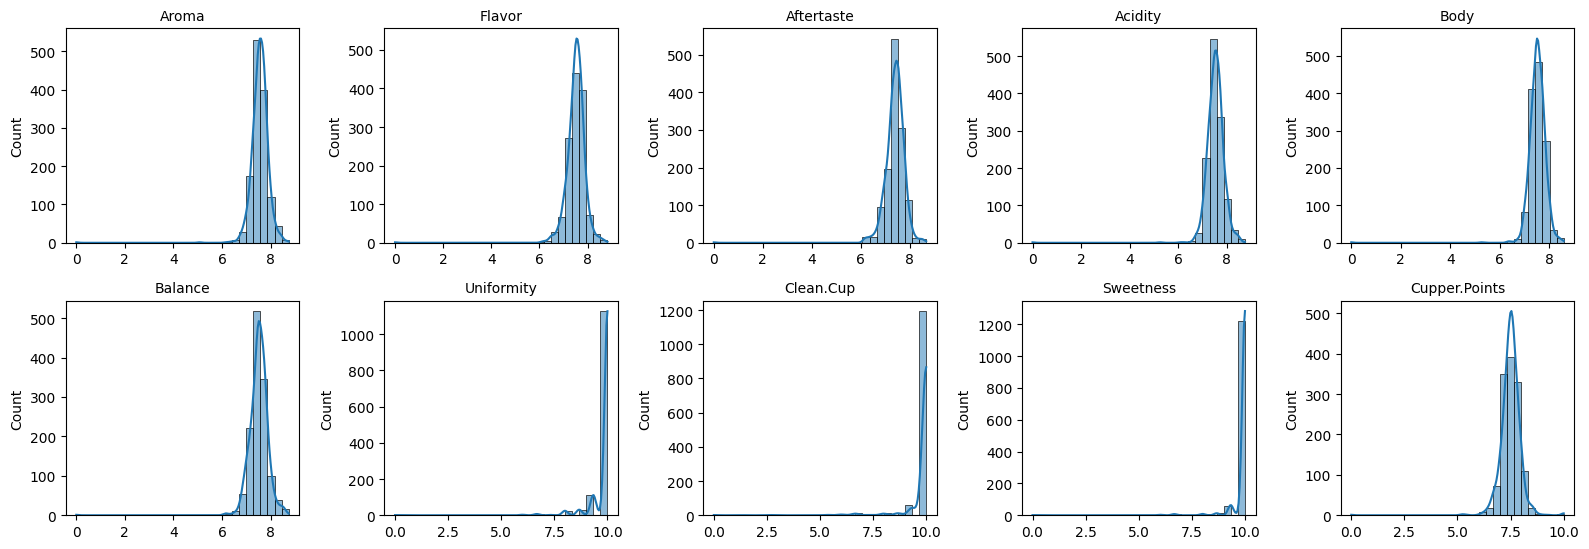

In [52]:
plot_feature_distributions(df_arabica, SCA_FEATURES, config,
                           "distribucion_subpuntajes_sca.png", ncols=5)
plt.show()

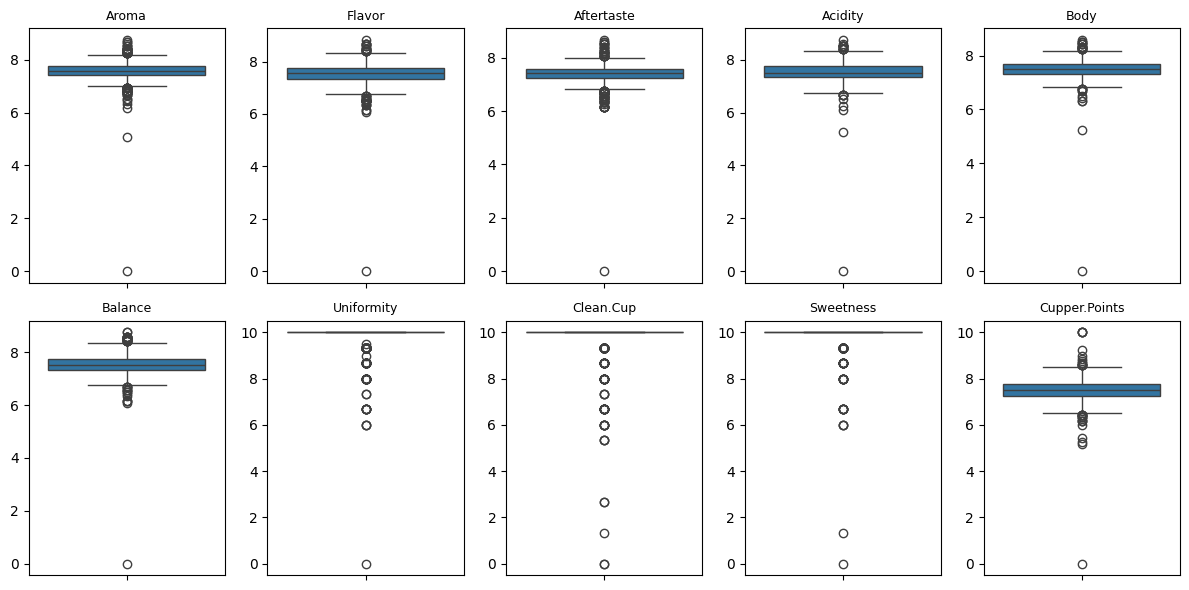

In [53]:
plot_boxplots(df_arabica, SCA_FEATURES, config, "boxplots_subpuntajes_sca.png", ncols=5)
plt.show()

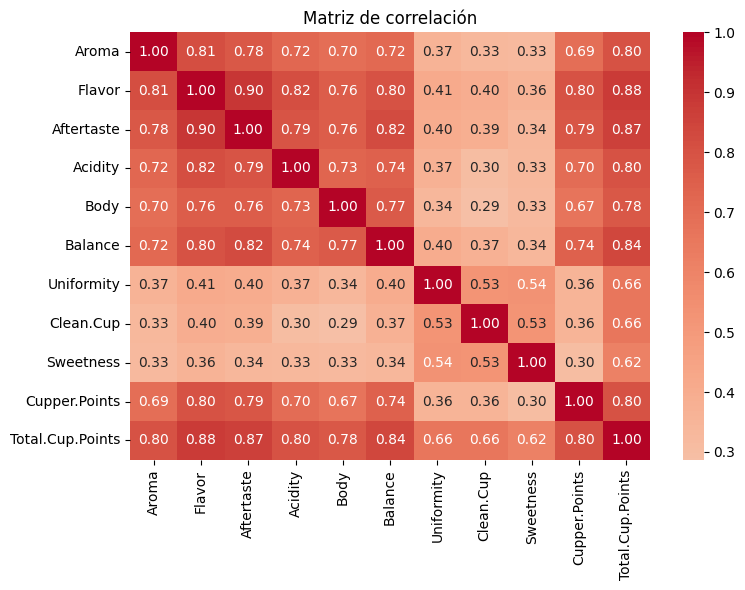

In [54]:
plot_correlation_heatmap(df_arabica, SCA_FEATURES + [REFERENCE_COLUMN], config,
                         "correlacion_subpuntajes_sca.png")
plt.show()

In [55]:
# El registro con Total.Cup.Points == 0 (¿un caso o varios?)
df_arabica.loc[df_arabica[REFERENCE_COLUMN] == 0, SCA_FEATURES + [REFERENCE_COLUMN,
               "Country.of.Origin", "Variety", "Processing.Method"]]

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Country.of.Origin,Variety,Processing.Method
1310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Honduras,Caturra,NaN


**Hallazgo.** En los histogramas, los subpuntajes de catación (`Aroma`, `Flavor`, `Aftertaste`, `Acidity`, `Body`, `Balance`, `Cupper.Points`) se concentran en curvas compactas alrededor de 7.5, mientras que `Uniformity`, `Clean.Cup` y `Sweetness` se amontonan en 10. Sin embargo, en los boxplots todas estas variables muestran un punto muy por debajo del bigote inferior, separado del resto.

Al revisarlo, resulta que ese punto es el mismo lote en todas las columnas: el registro 1310, que tiene `0` en toda la catación y en `Total.Cup.Points`. No es una nube de lotes de mala calidad, sino un único registro que parece no haber sido evaluado o haberse cargado mal. Se decide eliminar este registro para que en el clustering, este no forme su propio grupo.

### 2.4.2 Variables físicas y de perfilado numéricas

In [56]:
num_perfilado = ["Number.of.Bags", "altitude_mean_meters", "Moisture",
                 "Category.One.Defects", "Category.Two.Defects", "Quakers"]
df_arabica[num_perfilado].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Number.of.Bags,1311.0,153.89,129.73,0.0,14.50,175.00,275.00,1062.00
altitude_mean_meters,1084.0,1784.20,8767.02,1.0,1100.00,1310.64,1600.00,190164.00
Moisture,1311.0,0.09,0.05,0.0,0.09,0.11,0.12,0.28
Category.One.Defects,1311.0,0.43,1.83,0.0,0.00,0.00,0.00,31.00
Category.Two.Defects,1311.0,3.59,5.35,0.0,0.00,2.00,4.00,55.00
Quakers,1310.0,0.18,0.84,0.0,0.00,0.00,0.00,11.00


In [ ]:
# Altitud: valores imposibles
alt = df_arabica["altitude_mean_meters"]
print("lotes con altitud <= 1 m:", int((alt <= 1).sum()))
print("lotes con altitud > 4000 m:", int((alt > 4000).sum()))

# Los 10 lotes con mayor altitud registrada
df_arabica.nlargest(10, "altitude_mean_meters")[[ "altitude_mean_meters"]]

lotes con altitud <= 1 m: 12
lotes con altitud > 4000 m: 6


,altitude_mean_meters
896,190164.0
1144,190164.0
1040,110000.0
543,11000.0
1098,4287.0
840,4001.0
628,3850.0
1123,3845.0
1038,3825.0
1073,3800.0


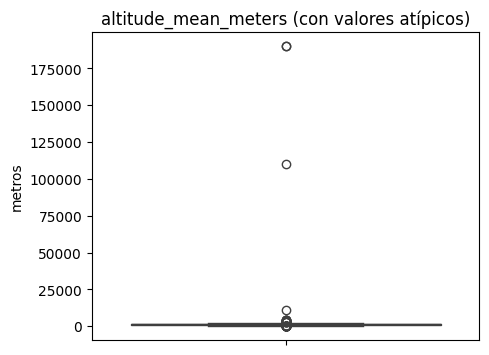

In [58]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(y=alt.dropna(), ax=ax)
ax.set_title("altitude_mean_meters (con valores atípicos)")
ax.set_ylabel("metros")
_fig_dir = resolve_path(config['paths']['reports']['figures_dir'])
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "boxplot_altitude_mean.png", bbox_inches="tight", dpi=150)
plt.show()

In [75]:
print("Moisture == 0 (humedad exactamente cero):",
      int((df_arabica['Moisture'] == 0).sum()),
      f"({(df_arabica['Moisture'] == 0).mean()*100:.1f}% de los lotes)")

Moisture == 0 (humedad exactamente cero): 252 (19.2% de los lotes)


**Hallazgos.**

- `altitude_mean_meters` tiene valores imposibles: el máximo es **190 164 metros**, y hay otros en 11 000 y 110 000, claramente errores de digitación, ya que ninguna finca cafetera supera los 2 500 o 3 000 metros. En el otro extremo, **12 lotes** tienen una altitud de 1 metro o menos, igual de inválida. Estos pocos valores hacen que la desviación estándar (~8 700) sea varias veces mayor que la media (~1 780), así que hay que recortar o winsorizar esta variable en la fase 03, o la variable terminará distorsionando el perfilado de los grupos.
- `Moisture` tiene **252 lotes (~19 %)** con un valor de exactamente 0, y la humedad del grano verde nunca es 0 %, ya que el rango real está entre 8 % y 13 % aproximadamente. Esos ceros parecen ser datos faltantes codificados como cero, no mediciones reales, así que conviene tratarlos como nulos en la fase 03.
- `Category.One.Defects` es 0 en la gran mayoría de los lotes (mediana 0, máximo 31), y `Category.Two.Defects` está sesgada hacia la derecha (mediana 2, máximo 55). Esto no parece ser un error, sino un reflejo de que casi todos los lotes de la base son de calidad relativamente alta, por lo que estas variables podrían servir como criterio de apoyo para definir "calidad" en la fase 03.
- `Number.of.Bags` va de 0 a cerca de 1 060 bolsas; algunos ceros probablemente correspondan a lotes de muestra, pero no es algo crítico para el análisis.

## 2.5 Variables cualitativas: describe y frecuencias

In [60]:
cat_cols = df_arabica.select_dtypes(include=["object", "string", "category"]).columns
df_arabica[cat_cols].describe().T

,count,unique,top,freq
Species,1311,1,Arabica,1311
Owner,1304,305,juan luis alvarado romero,155
Country.of.Origin,1310,36,Mexico,236
Farm.Name,955,557,various,47
Lot.Number,270,221,1,18
Mill,1001,447,beneficio ixchel,90
ICO.Number,1163,840,0,67
Company,1102,270,"unex guatemala, s.a.",86
Altitude,1088,383,1100,43
Region,1254,343,huila,112


In [61]:
for col in ["Species", "Country.of.Origin", "Region", "Variety",
            "Processing.Method", "Color", "Harvest.Year"]:
    print(f"\n=== {col} — {df_arabica[col].nunique(dropna=True)} categorías, "
          f"{df_arabica[col].isna().sum()} nulos ===")
    print(df_arabica[col].value_counts(dropna=False).head(8))


=== Species — 1 categorías, 0 nulos ===
Species
Arabica    1311
Name: count, dtype: int64

=== Country.of.Origin — 36 categorías, 1 nulos ===
Country.of.Origin
Mexico                    236
Colombia                  183
Guatemala                 181
Brazil                    132
Taiwan                     75
United States (Hawaii)     73
Honduras                   53
Costa Rica                 51
Name: count, dtype: int64

=== Region — 343 categorías, 57 nulos ===
Region
huila             112
oriente            80
south of minas     68
kona               66
NaN                57
veracruz           35
tarrazu            19
comayagua          17
Name: count, dtype: int64

=== Variety — 29 categorías, 201 nulos ===
Variety
Caturra           256
Bourbon           226
Typica            211
NaN               201
Other             108
Catuai             74
Hawaiian Kona      44
Yellow Bourbon     35
Name: count, dtype: int64

=== Processing.Method — 5 categorías, 152 nulos ===
Processing.Met

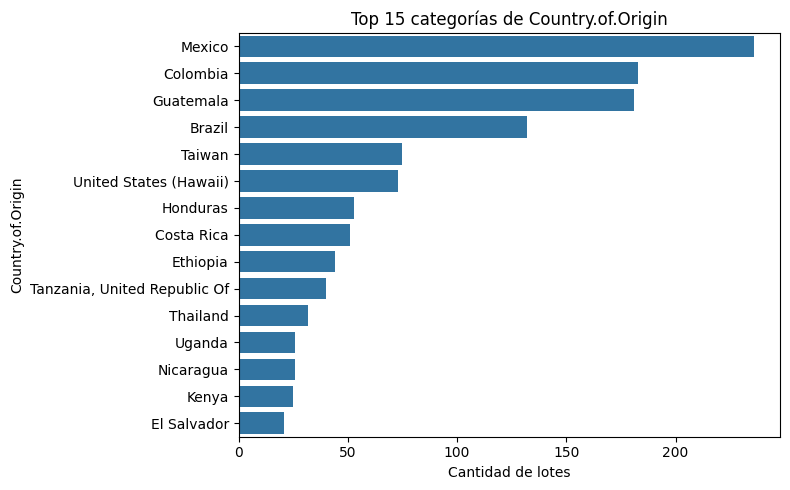

In [62]:
plot_categorical_counts(df_arabica, "Country.of.Origin", config,
                        "frecuencia_paises_origen.png", top_n=15)
plt.show()

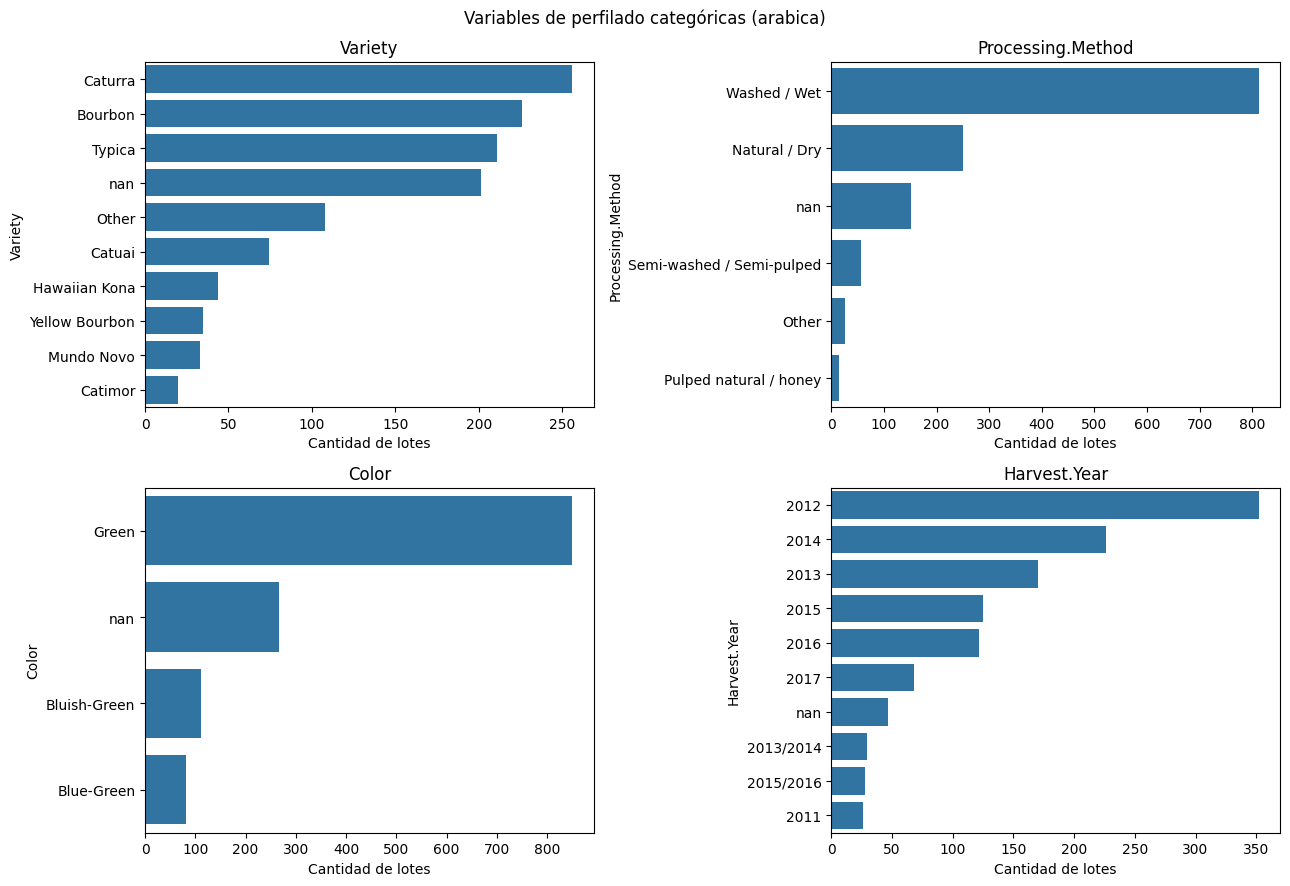

In [63]:
# Frecuencia de las variables de perfilado categóricas, en una sola figura
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ["Variety", "Processing.Method", "Color", "Harvest.Year"]):
    vc = df_arabica[col].value_counts(dropna=False).head(10)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, orient="h")
    ax.set_title(col); ax.set_xlabel("Cantidad de lotes")
fig.suptitle("Variables de perfilado categóricas (arabica)")
fig.tight_layout()
fig.savefig(resolve_path(config['paths']['reports']['figures_dir']) / "frecuencia_cualitativas.png",
            bbox_inches="tight", dpi=150)
plt.show()

**Hallazgos.**

- `Species` es constante: las **1 311 filas** son `Arabica`. Solo tendría sentido como variable si en algún momento se combinan las dos especies.
- `Country.of.Origin` tiene **36 países** y solo **1 valor nulo**, con una fuerte concentración en México (236 lotes), Colombia (183), Guatemala (181) y Brasil (132). La cola larga de países con pocos lotes hará que algunos perfiles por país sean poco fiables, algo que hay que tener presente al interpretar los resultados.
- `Region` tiene **343 valores distintos**, escritos en minúsculas.
- `Variety` tiene **29 categorías** y un **15 % de nulos**. Predominan `Caturra`, `Bourbon` y `Typica`, hay una categoría genérica `Other` con 108 lotes, y probablemente varias inconsistencias de escritura. Necesita estandarización e imputación de datos.
- `Processing.Method` tiene solo **5 categorías** y un **12 % de nulos**; `Washed / Wet` domina con 812 lotes, por lo que es fácil de estandarizar.
- `Color` tiene **3 categorías** (`Green`, `Bluish-Green`, `Blue-Green`) y un **20 % de nulos**.
- `Harvest.Year` tiene **46 valores distintos** que mezclan años simples (`2012`, `2014`), rangos (`2013/2014`) y entradas de texto libre. Si se quiere usar, hay que convertirla a un año numérico en la fase 03.

## 2.6 Variable de referencia: `Total.Cup.Points`

Al ser un proyecto de clustering, `Total.Cup.Points` no es una variable objetivo, como sí lo sería en un problema de clasificación o regresión. Aun así, vale la pena describirla aquí porque en la fase 05 se usará como referencia para contrastar los grupos obtenidos con el clustering frente a la convención de la industria, según la cual un café con un puntaje de 80 o más se considera como "café de especialidad".

In [64]:
df_arabica[REFERENCE_COLUMN].describe()

count    1311.000000
mean       82.115927
std         3.515761
min         0.000000
25%        81.170000
50%        82.500000
75%        83.670000
max        90.580000
Name: Total.Cup.Points, dtype: float64

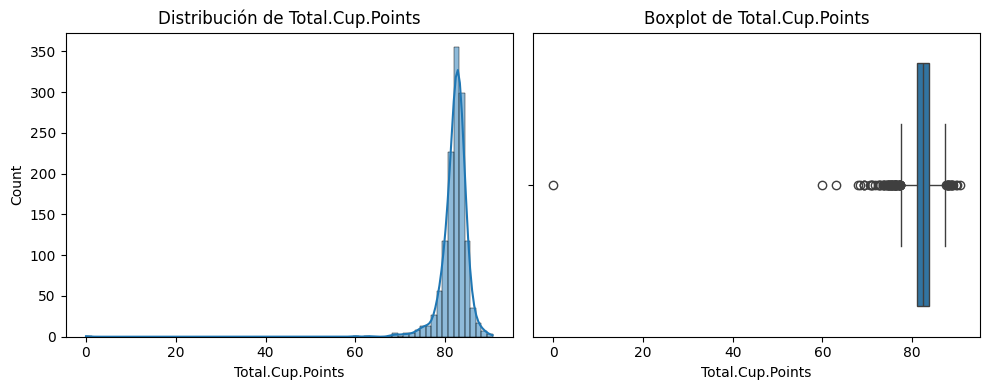

In [65]:
plot_score_distribution(df_arabica, REFERENCE_COLUMN, config,
                        "distribucion_total_cup_points.png")
plt.show()

In [66]:
sin_corruptos = df_arabica[df_arabica[REFERENCE_COLUMN] > 0]
pct = (sin_corruptos[REFERENCE_COLUMN] >= SPECIALTY_THRESHOLD).mean() * 100
print(f"Lotes con Total.Cup.Points >= {SPECIALTY_THRESHOLD} "
      f"(excluyendo el registro en 0): {pct:.1f}%")

Lotes con Total.Cup.Points >= 80 (excluyendo el registro en 0): 86.3%


**Hallazgos.**

- Excluyendo el registro corrupto, `Total.Cup.Points` se distribuye de forma aproximadamente normal alrededor de **82-83 puntos**, con un mínimo real cercano a 59 y un máximo cercano a 91.
- Cerca del **90 % de los lotes** supera el umbral de 80 puntos, es decir, casi toda la base ya sería "de especialidad" según la convención SCA. Esto confirma el sesgo de selección que se anticipó en la fase 01 (la base reúne lotes que buscan certificación) y explica por qué tiene más sentido dejar que el clustering encuentre sus propios grupos de calidad, en vez de aplicar un corte fijo en 80 que dejaría un grupo minúsculo.
- El registro en 0 aparece como un punto totalmente separado del resto, lo que confirma visualmente que es un dato corrupto.

## 2.7 Conclusiones: qué se debe tratar en la fase de preparación

A partir de los hallazgos anteriores, estas son las acciones concretas que se deben ejecutar en la siguiente fase, agrupadas por tipo. 

### Eliminar

| Qué se elimina | Motivo |
|---|---|
| **Fila del registro 1310** | Tiene `0` en los 10 subpuntajes y en `Total.Cup.Points`; no es un lote evaluado, y sin quitarlo formaría su propio grupo y distorsionaría la escala de las demás variables. |
| Columna `Unnamed: 0` | Es solo el índice de fila del CSV original, no aporta información. |
| Columnas `Lot.Number`, `Farm.Name`, `Mill`, `ICO.Number`, `Producer`, `Company` | Identificadores administrativos con alta nulidad (hasta 79 %); no se usan ni para agrupar ni para perfilar. |
| Columnas `Altitude`, `altitude_low_meters`, `altitude_high_meters` | Redundantes con `altitude_mean_meters` (y `Altitude` es texto libre). Se conserva solo la media. |
| Columna `Region` | 343 valores de texto libre en minúsculas, sin estandarizar; no es usable tal cual. |

### Se tiene que decidir entre opciones

| Decisión | Opciones |
|---|---|
| **Especie a analizar** (`dataset.species`) | Trabajar **solo con arabica o combinar ambas** mapeando las columnas equivalentes, se tiene que tener en cuenta que la base de datos de robusta usa un formulario sensorial distinto y solo tiene 28 filas. |
| **Subpuntajes que entran al clustering** (`clustering.features`) | Incluir los 10, o excluir `Uniformity`, `Clean.Cup` y `Sweetness`, que son casi constantes en 10 y aportan muy poca separación entre lotes. |
| **Uso de `Harvest.Year`** | Convertirla a un año numérico o descartarla si no se usa en el perfilado. |

### Tratar valores imposibles o inavlidos

| Variable | Acción |
|---|---|
| `altitude_mean_meters` | Recortar / winsorizar a un rango plausible: los **6 lotes con altitud > ~3 000 m** y los **12 lotes con altitud ≤ 1 m**|
| `Moisture` | Tratar los **252 registros (~19 %) con humedad igual a 0**.|
| `Country.of.Origin` | Resolver el **único registro con país nulo** |

### Imputar valores faltantes

| Variable(s) | Estrategia |
|---|---|
| `altitude_mean_meters` (tras el recorte anterior) | Imputar con la mediana. |
| `Variety`, `Processing.Method`, `Color` | Imputar como categoría `"Desconocido"` |

### Se resuelve en fases posteriores

- **Definición de "calidad".** La gran mayoría de los lotes ya supera los 80 puntos, así que un corte fijo dejaría un grupo minúsculo. Se deja que el clustering (fase 04) forme los grupos y se contrastan contra `Total.Cup.Points >= 80` en la fase 05. `Category.One.Defects` y `Category.Two.Defects` pueden servir como criterio de apoyo para caracterizar los grupos.
- **Fiabilidad por país.** La cola larga de países con pocos lotes se tiene en cuenta al interpretar los perfiles (fase 06), no se corrige en los datos.